In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("karimabdulnabi/fruit-classification10-class")
dataset_path = os.path.join(dataset_path, "MY_data")
# Setup path to data folder
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
predict_dir = os.path.join(dataset_path, "predict")

train_dir, test_dir


100%|██████████| 29.2M/29.2M [00:00<00:00, 94.4MB/s]

Extracting files...


('/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/train',
 '/root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/test')

In [4]:
#testing out data transformations on fruit dataset classification
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),transforms.ToTensor()
])

In [5]:
# Creating dataset for fruit classification
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")


Train data:
Dataset ImageFolder
    Number of datapoints: 2301
    Root location: /root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 1025
    Root location: /root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [6]:
train_dataloader = DataLoader(dataset=train_data,batch_size=1,num_workers=1,shuffle=True)

test_dataloader = DataLoader(dataset=test_data,batch_size=1,num_workers=1,shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bc4d8c7fc70>,
 <torch.utils.data.dataloader.DataLoader at 0x7bc5b0a0db70>)

In [7]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [8]:
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_simple = DataLoader(train_data_simple,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7bc5b156f130>,
 <torch.utils.data.dataloader.DataLoader at 0x7bc5b0a0d840>)

In [9]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=10, bias=True)
  )
)

In [10]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)


        loss = loss_fn(y_pred, y)
        train_loss += loss.item()


        optimizer.zero_grad()


        loss.backward()


        optimizer.step()


        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [11]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    model.eval()

    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Check DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Data is sent to target decvice
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            #Determine  accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [12]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)


        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [13]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)


NUM_EPOCHS = 10

first_model= TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=first_model.parameters(), lr=0.001)


from timeit import default_timer as timer
start_time = timer()


first_model_results = train(model=first_model,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2956 | train_acc: 0.1119 | test_loss: 2.2181 | test_acc: 0.2169
Epoch: 2 | train_loss: 1.9877 | train_acc: 0.2356 | test_loss: 1.9474 | test_acc: 0.2680
Epoch: 3 | train_loss: 1.6622 | train_acc: 0.3687 | test_loss: 1.8785 | test_acc: 0.2945
Epoch: 4 | train_loss: 1.5296 | train_acc: 0.4273 | test_loss: 1.7958 | test_acc: 0.3182
Epoch: 5 | train_loss: 1.4411 | train_acc: 0.4703 | test_loss: 1.7844 | test_acc: 0.3977
Epoch: 6 | train_loss: 1.3930 | train_acc: 0.4985 | test_loss: 1.7793 | test_acc: 0.3892
Epoch: 7 | train_loss: 1.3378 | train_acc: 0.5156 | test_loss: 1.9100 | test_acc: 0.3958
Epoch: 8 | train_loss: 1.3114 | train_acc: 0.5246 | test_loss: 1.7745 | test_acc: 0.4205
Epoch: 9 | train_loss: 1.2659 | train_acc: 0.5375 | test_loss: 1.8963 | test_acc: 0.3589
Epoch: 10 | train_loss: 1.2356 | train_acc: 0.5555 | test_loss: 1.8431 | test_acc: 0.3352
Total training time: 38.017 seconds


In [14]:
from typing import Dict, List
def plot_loss_curves(results: Dict[str, List[float]]):


    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.legend()

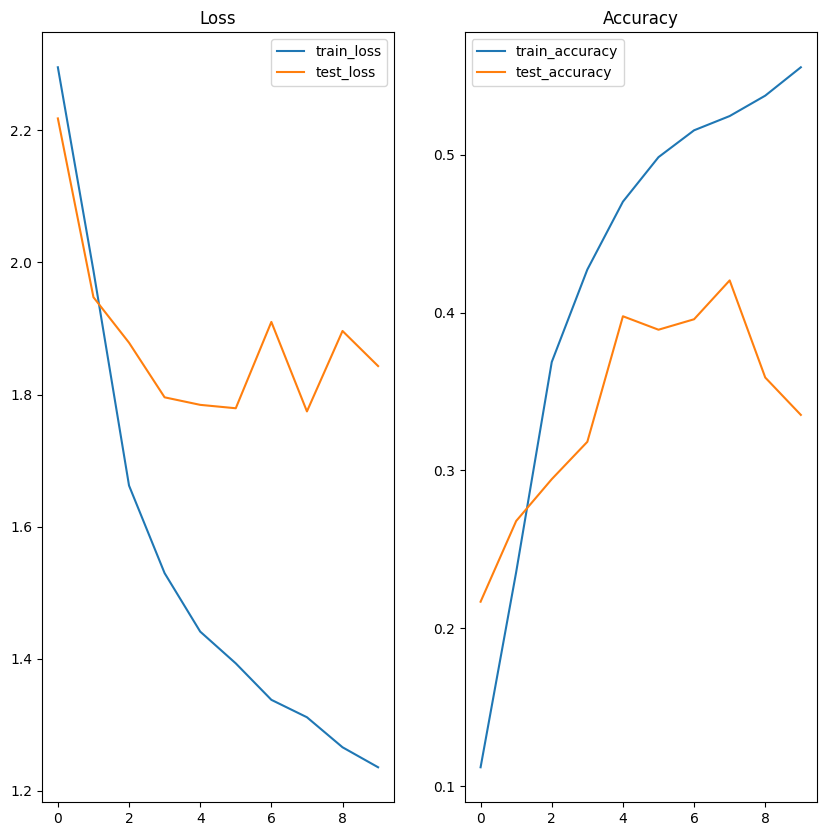

In [15]:
plot_loss_curves(first_model_results)

In [16]:

train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transform (no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [17]:
# Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 2301
     Root location: /root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 1025
     Root location: /root/.cache/kagglehub/datasets/karimabdulnabi/fruit-classification10-class/versions/1/MY_data/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [18]:

import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bc4bdcb6cb0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bc5b0a0db70>)

In [19]:
torch.manual_seed(42)
torch.manual_seed(42)
model_two = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_two

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=10, bias=True)
  )
)

In [20]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_two.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

#Training Model two
model_two_results = train(model=model_two,train_dataloader=train_dataloader_augmented,test_dataloader=test_dataloader_simple,optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.3023 | train_acc: 0.0997 | test_loss: 2.2780 | test_acc: 0.0900
Epoch: 2 | train_loss: 2.2142 | train_acc: 0.1351 | test_loss: 2.1399 | test_acc: 0.2027
Epoch: 3 | train_loss: 1.9946 | train_acc: 0.2318 | test_loss: 1.8916 | test_acc: 0.2595
Epoch: 4 | train_loss: 1.8411 | train_acc: 0.2965 | test_loss: 1.9096 | test_acc: 0.2652
Epoch: 5 | train_loss: 1.7861 | train_acc: 0.3068 | test_loss: 1.7657 | test_acc: 0.2850
Epoch: 6 | train_loss: 1.7277 | train_acc: 0.3482 | test_loss: 1.8506 | test_acc: 0.2926
Epoch: 7 | train_loss: 1.6931 | train_acc: 0.3659 | test_loss: 1.7240 | test_acc: 0.2784
Epoch: 8 | train_loss: 1.6769 | train_acc: 0.3628 | test_loss: 1.7125 | test_acc: 0.3608
Epoch: 9 | train_loss: 1.6257 | train_acc: 0.3956 | test_loss: 1.7713 | test_acc: 0.3703
Epoch: 10 | train_loss: 1.6303 | train_acc: 0.4133 | test_loss: 1.7144 | test_acc: 0.3513
Total training time: 45.531 seconds


In [21]:
first_model_df = pd.DataFrame(first_model_results)
model_two_df = pd.DataFrame(model_two_results)
first_model_df

,train_loss,train_acc,test_loss,test_acc
0,2.295561,0.111949,2.218122,0.216856
1,1.987712,0.235602,1.947406,0.267992
2,1.662202,0.368729,1.878510,0.294508
3,1.529570,0.427323,1.795811,0.318182
4,1.441084,0.470336,1.784413,0.397727
5,1.392967,0.498548,1.779258,0.389205
6,1.337776,0.515565,1.909981,0.395833
7,1.311384,0.524590,1.774470,0.420455
8,1.265927,0.537521,1.896276,0.358902
9,1.235640,0.555496,1.843143,0.335227


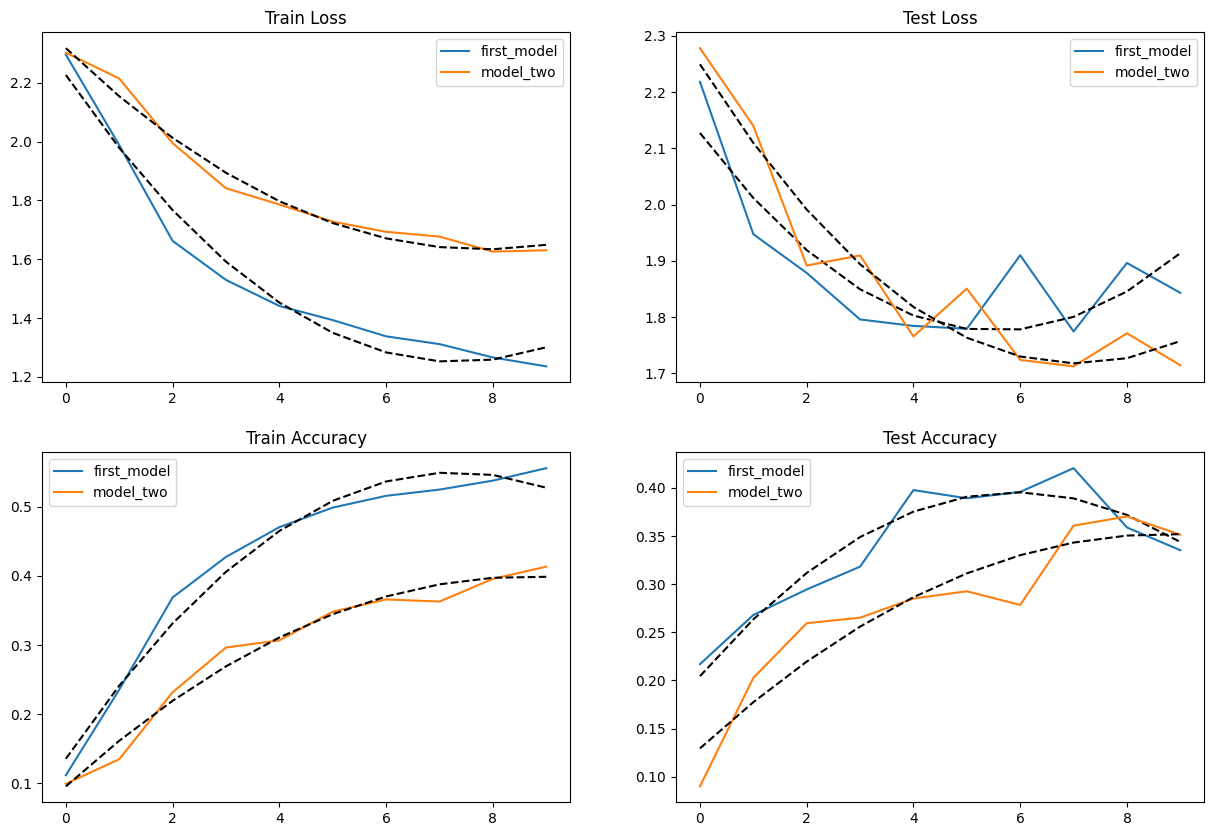

In [22]:

plt.figure(figsize=(15, 10))


epochs = range(len(first_model_df))

def add_best_fit(x, y):
    coeffs = np.polyfit(x, y, 2)
    best_fit_line = np.poly1d(coeffs)
    plt.plot(x, best_fit_line(x), linestyle="--", color="black")

# train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, first_model_df["train_loss"], label="first_model")
add_best_fit(epochs, first_model_df["train_loss"])
plt.plot(epochs, model_two_df["train_loss"], label="model_two")
add_best_fit(epochs, model_two_df["train_loss"])
plt.title("Train Loss")
plt.legend()

# test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, first_model_df["test_loss"], label="first_model")
add_best_fit(epochs, first_model_df["test_loss"])
plt.plot(epochs, model_two_df["test_loss"], label="model_two")
add_best_fit(epochs, model_two_df["test_loss"])
plt.title("Test Loss")
plt.legend()

#train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, first_model_df["train_acc"], label="first_model")
add_best_fit(epochs, first_model_df["train_acc"])
plt.plot(epochs, model_two_df["train_acc"], label="model_two")
add_best_fit(epochs, model_two_df["train_acc"])
plt.title("Train Accuracy")
plt.legend()

# test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, first_model_df["test_acc"], label="first_model")
add_best_fit(epochs, first_model_df["test_acc"])
plt.plot(epochs, model_two_df["test_acc"], label="model_two")
add_best_fit(epochs, model_two_df["test_acc"])
plt.title("Test Accuracy")
plt.legend()

plt.figure(figsize=(15,10))
plt.plot(model_two_df["train_loss"], marker='o', label = 'Second Model Results')
plt.title('Second Model Results')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show(0)

In [23]:
fruit_image_path = os.path.join(predict_dir, "img_411.jpeg")

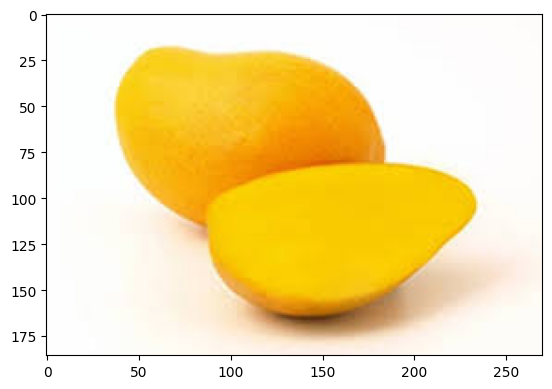

In [24]:
import matplotlib.image as mpimg
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()

In [25]:
fruit_image_transform = transforms.Compose([transforms.Resize((64, 64)),])

In [26]:
def predictImage(model: torch.nn.Module,  image_path: str, class_names: List[str] = None, transform=None,device: torch.device = device):

    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    target_image = target_image / 255.

    if transform:
        target_image = transform(target_image)

    model.to(device)

    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(dim=0)

        target_image_pred = model(target_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)


    plt.imshow(target_image.squeeze().permute(1, 2, 0))
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

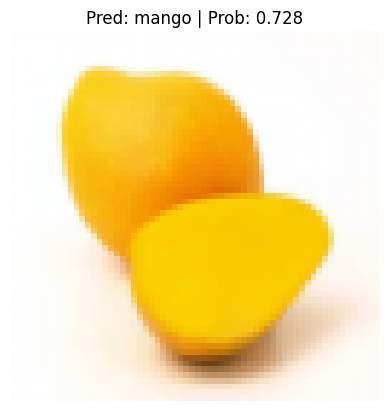

In [27]:
predictImage(model=model_two,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

In [28]:
class TinyVGGWithDropout(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=hidden_units*16*16, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [29]:
class CNNWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        #Defining 2 convolutional layers
        self.convlay1 = nn.Conv2d(3, 6, 5, 1)
        self.convlay2 = nn.Conv2d(6, 16, 5, 1)
        #Defining pooling layer
        self.pool = nn.MaxPool2d(2,2)

        self.dropout = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.4)

        #Defining 3 fully connected layers
        self.fullyconlay1 = nn.Linear(16 * 13 * 13, 120)
        self.fullyconlay2 = nn.Linear(120, 84)
        self.fullyconlay3 = nn.Linear(84, 10) #Final output channels need to be 10

    def forward(self, image_data):
        #First pass
        image_data = F.relu(self.convlay1(image_data)) #Featured maps
        image_data = self.pool(image_data) #Pooled featured maps
        image_data = self.dropout(image_data)
        #Second pass
        image_data = F.relu(self.convlay2(image_data)) #Featured maps
        image_data = self.pool(image_data) #Pooled featured maps
        image_data = self.dropout(image_data)

        #Flatten layer
        image_data = torch.flatten(image_data, 1)
        #Pass through fully connected layers using relu
        image_data = F.relu(self.fullyconlay1(image_data))
        image_data = F.relu(self.fullyconlay2(image_data))
        image_data = self.dropout2(image_data)
        return self.fullyconlay3(image_data)

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS = 10

model_3= TinyVGGWithDropout(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

model_3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.001)


from timeit import default_timer as timer
start_time = timer()


model_3_results = train(model=model_3,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.3094 | train_acc: 0.0956 | test_loss: 2.3033 | test_acc: 0.1013
Epoch: 2 | train_loss: 2.2134 | train_acc: 0.1479 | test_loss: 2.0876 | test_acc: 0.2159
Epoch: 3 | train_loss: 1.7984 | train_acc: 0.3015 | test_loss: 1.8246 | test_acc: 0.2623
Epoch: 4 | train_loss: 1.5627 | train_acc: 0.4173 | test_loss: 1.7388 | test_acc: 0.3409
Epoch: 5 | train_loss: 1.4803 | train_acc: 0.4454 | test_loss: 1.6905 | test_acc: 0.3911
Epoch: 6 | train_loss: 1.4369 | train_acc: 0.4729 | test_loss: 1.6712 | test_acc: 0.3778
Epoch: 7 | train_loss: 1.3683 | train_acc: 0.5032 | test_loss: 1.6778 | test_acc: 0.3902
Epoch: 8 | train_loss: 1.3327 | train_acc: 0.5125 | test_loss: 1.6587 | test_acc: 0.3949
Epoch: 9 | train_loss: 1.3095 | train_acc: 0.5165 | test_loss: 1.8289 | test_acc: 0.3409
Epoch: 10 | train_loss: 1.2525 | train_acc: 0.5477 | test_loss: 1.6989 | test_acc: 0.3665
Total training time: 36.639 seconds


In [31]:
model_3_df = pd.DataFrame(model_3_results)
model_3_df

,train_loss,train_acc,test_loss,test_acc
0,2.309394,0.095621,2.303341,0.101326
1,2.213370,0.147884,2.087559,0.215909
2,1.798449,0.301455,1.824638,0.262311
3,1.562712,0.417340,1.738794,0.340909
4,1.480330,0.445417,1.690458,0.391098
5,1.436862,0.472941,1.671226,0.377841
6,1.368326,0.503233,1.677818,0.390152
7,1.332719,0.512527,1.658706,0.394886
8,1.309497,0.516463,1.828852,0.340909
9,1.252486,0.547728,1.698927,0.366477


In [32]:
#TESTING THE 2 IMPROVEMENTS TOGETHER: TINYVNN WITH DROPOUT AND DATA AUGMENTATION
torch.manual_seed(42)
torch.manual_seed(42)
model_4 = TinyVGGWithDropout(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_4

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_4.parameters(), lr=0.001)


from timeit import default_timer as timer
start_time = timer()


model_4_results = train(model=model_4,train_dataloader=train_dataloader_augmented,test_dataloader=test_dataloader_simple,optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.3080 | train_acc: 0.0987 | test_loss: 2.2973 | test_acc: 0.1326
Epoch: 2 | train_loss: 2.2225 | train_acc: 0.1595 | test_loss: 2.2217 | test_acc: 0.1818
Epoch: 3 | train_loss: 2.1119 | train_acc: 0.1927 | test_loss: 2.0508 | test_acc: 0.2330
Epoch: 4 | train_loss: 1.8796 | train_acc: 0.2678 | test_loss: 1.8035 | test_acc: 0.3002
Epoch: 5 | train_loss: 1.7780 | train_acc: 0.3274 | test_loss: 1.7826 | test_acc: 0.2566
Epoch: 6 | train_loss: 1.7344 | train_acc: 0.3488 | test_loss: 1.7900 | test_acc: 0.2850
Epoch: 7 | train_loss: 1.7016 | train_acc: 0.3373 | test_loss: 1.7225 | test_acc: 0.2973
Epoch: 8 | train_loss: 1.7156 | train_acc: 0.3530 | test_loss: 1.8021 | test_acc: 0.2812
Epoch: 9 | train_loss: 1.6872 | train_acc: 0.3521 | test_loss: 1.8210 | test_acc: 0.2945
Epoch: 10 | train_loss: 1.6814 | train_acc: 0.3709 | test_loss: 1.7627 | test_acc: 0.3021
Total training time: 44.309 seconds


In [33]:
model_4_df = pd.DataFrame(model_4_results)
model_4_df

,train_loss,train_acc,test_loss,test_acc
0,2.307963,0.098659,2.297301,0.132576
1,2.222482,0.159468,2.221726,0.181818
2,2.111920,0.192723,2.050840,0.232955
3,1.879617,0.267765,1.803541,0.300189
4,1.777982,0.327362,1.782605,0.256629
5,1.734445,0.348839,1.790011,0.285038
6,1.701624,0.337344,1.722479,0.297348
7,1.715628,0.352969,1.802081,0.281250
8,1.687213,0.352056,1.820957,0.294508
9,1.681426,0.370944,1.762684,0.302083


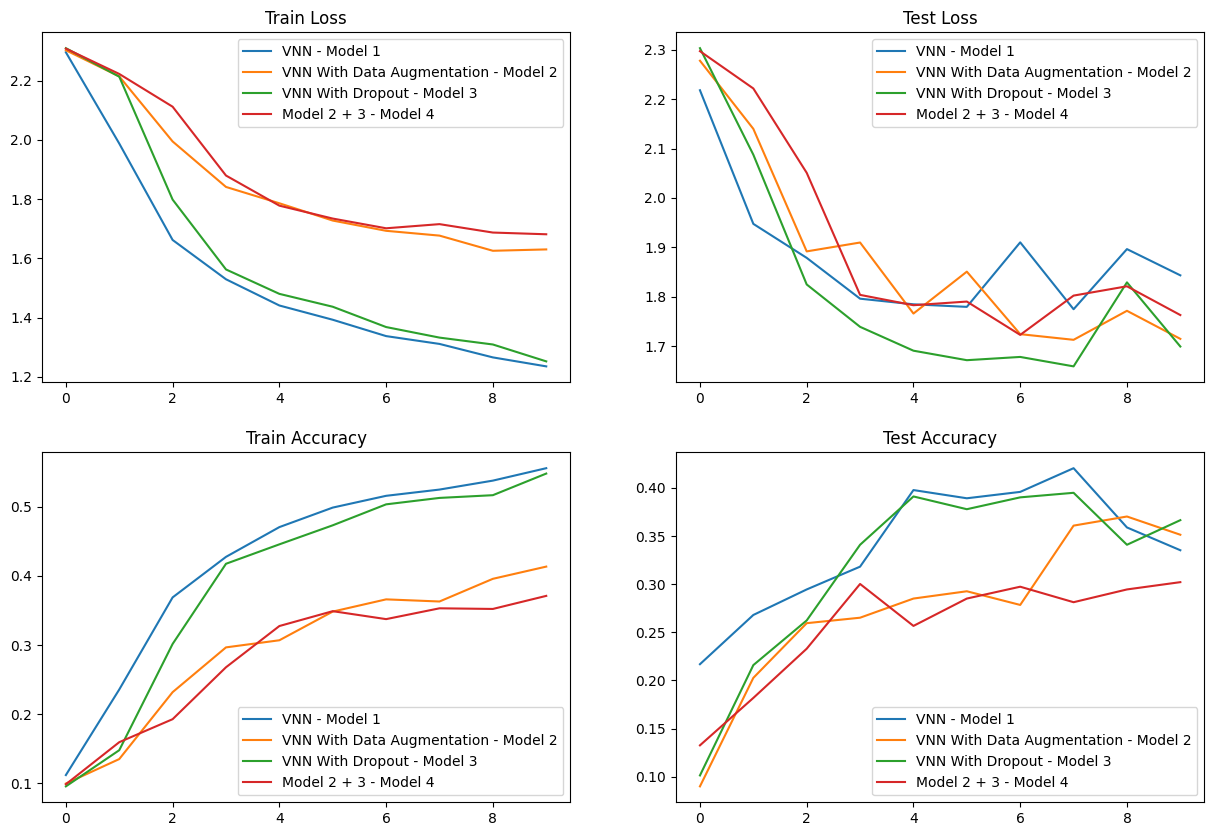

In [34]:

plt.figure(figsize=(15, 10))


epochs = range(len(first_model_df))

# train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, first_model_df["train_loss"], label="VNN - Model 1")
plt.plot(epochs, model_two_df["train_loss"], label="VNN With Data Augmentation - Model 2")
plt.plot(epochs, model_3_df["train_loss"], label="VNN With Dropout - Model 3")
plt.plot(epochs, model_4_df["train_loss"], label="Model 2 + 3 - Model 4")
plt.title("Train Loss")
plt.legend()

# test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, first_model_df["test_loss"], label="VNN - Model 1")
plt.plot(epochs, model_two_df["test_loss"], label="VNN With Data Augmentation - Model 2")
plt.plot(epochs, model_3_df["test_loss"], label="VNN With Dropout - Model 3")
plt.plot(epochs, model_4_df["test_loss"], label="Model 2 + 3 - Model 4")
plt.title("Test Loss")
plt.legend()

#train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, first_model_df["train_acc"], label="VNN - Model 1")
plt.plot(epochs, model_two_df["train_acc"], label="VNN With Data Augmentation - Model 2")
plt.plot(epochs, model_3_df["train_acc"], label="VNN With Dropout - Model 3")
plt.plot(epochs, model_4_df["train_acc"], label="Model 2 + 3 - Model 4")
plt.title("Train Accuracy")
plt.legend()

# test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, first_model_df["test_acc"], label="VNN - Model 1")
plt.plot(epochs, model_two_df["test_acc"], label="VNN With Data Augmentation - Model 2")
plt.plot(epochs, model_3_df["test_acc"], label="VNN With Dropout - Model 3")
plt.plot(epochs, model_4_df["test_acc"], label="Model 2 + 3 - Model 4")
plt.title("Test Accuracy")
plt.legend()

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2598 | train_acc: 0.1248 | test_loss: 2.0504 | test_acc: 0.1392
Epoch: 2 | train_loss: 2.0045 | train_acc: 0.1918 | test_loss: 1.8587 | test_acc: 0.2547
Epoch: 3 | train_loss: 1.9134 | train_acc: 0.2267 | test_loss: 1.8265 | test_acc: 0.2244
Epoch: 4 | train_loss: 1.8543 | train_acc: 0.2634 | test_loss: 1.7811 | test_acc: 0.2528
Epoch: 5 | train_loss: 1.8122 | train_acc: 0.2799 | test_loss: 1.7964 | test_acc: 0.2528
Epoch: 6 | train_loss: 1.8151 | train_acc: 0.2953 | test_loss: 1.7284 | test_acc: 0.2955
Epoch: 7 | train_loss: 1.7954 | train_acc: 0.2903 | test_loss: 1.7067 | test_acc: 0.3059
Epoch: 8 | train_loss: 1.7545 | train_acc: 0.3145 | test_loss: 1.7254 | test_acc: 0.3172
Epoch: 9 | train_loss: 1.7705 | train_acc: 0.3172 | test_loss: 1.7591 | test_acc: 0.3314
Epoch: 10 | train_loss: 1.7271 | train_acc: 0.3275 | test_loss: 1.7216 | test_acc: 0.2898
Total training time: 44.613 seconds


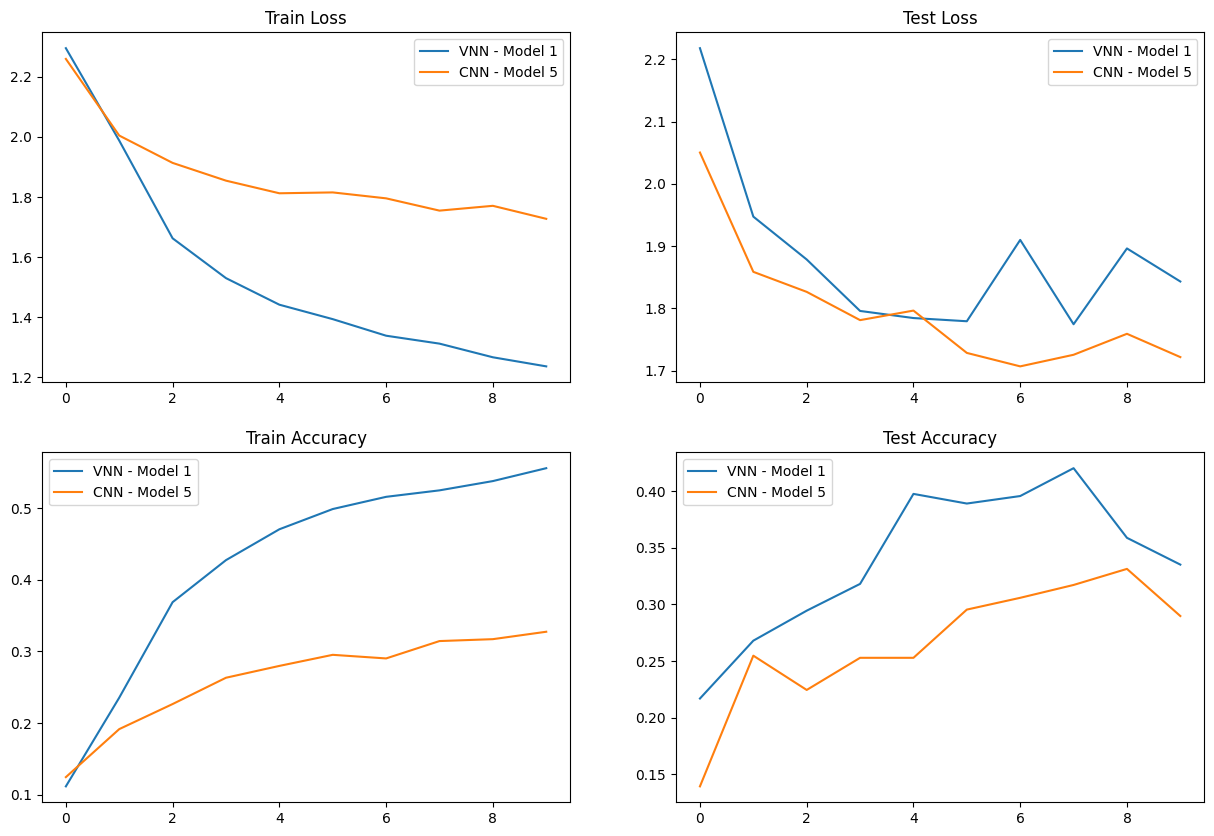

In [35]:
#TESTING CNNs
#CNN WITH DATA AUGMENTATION AND DROPOUT

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        #Defining 2 convolutional layers
        self.convlay1 = nn.Conv2d(3, 6, 5, 1)
        self.convlay2 = nn.Conv2d(6, 16, 5, 1)
        #Defining pooling layer
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.4)
        #Defining 3 fully connected layers
        self.fullyconlay1 = nn.Linear(16*13*13, 120)
        self.fullyconlay2 = nn.Linear(120, 84)
        self.fullyconlay3 = nn.Linear(84, 10) #Final output channels need to be 10

    def forward(self, image_data):
        #First pass
        image_data = F.relu(self.convlay1(image_data)) #Featured maps
        image_data = self.pool(image_data) #Pooled featured maps
        image_data = self.dropout(image_data)
        #Second pass
        image_data = F.relu(self.convlay2(image_data)) #Featured maps
        image_data = self.pool(image_data) #Pooled featured maps
        image_data = self.dropout(image_data)
        #Flatten layer
        image_data = torch.flatten(image_data, 1)
        #Pass through fully connected layers using relu
        image_data = F.relu(self.fullyconlay1(image_data))
        image_data = F.relu(self.fullyconlay2(image_data))
        image_data = self.dropout2(image_data)
        return self.fullyconlay3(image_data)

torch.manual_seed(42)
torch.manual_seed(42)
model_5 = CNN().to(device)
model_5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_5.parameters(), lr=0.001)


from timeit import default_timer as timer
start_time = timer()


model_5_results = train(model=model_5,train_dataloader=train_dataloader_augmented,test_dataloader=test_dataloader_simple,optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

model_5_df = pd.DataFrame(model_5_results)
model_5_df


plt.figure(figsize=(15, 10))


epochs = range(len(first_model_df))

# train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, first_model_df["train_loss"], label="VNN - Model 1")
plt.plot(epochs, model_5_df["train_loss"], label="CNN - Model 5")
plt.title("Train Loss")
plt.legend()

# test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, first_model_df["test_loss"], label="VNN - Model 1")
plt.plot(epochs, model_5_df["test_loss"], label="CNN - Model 5")
plt.title("Test Loss")
plt.legend()

#train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, first_model_df["train_acc"], label="VNN - Model 1")
plt.plot(epochs, model_5_df["train_acc"], label="CNN - Model 5")
plt.title("Train Accuracy")
plt.legend()

# test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, first_model_df["test_acc"], label="VNN - Model 1")
plt.plot(epochs, model_5_df["test_acc"], label="CNN - Model 5")
plt.title("Test Accuracy")
plt.legend()

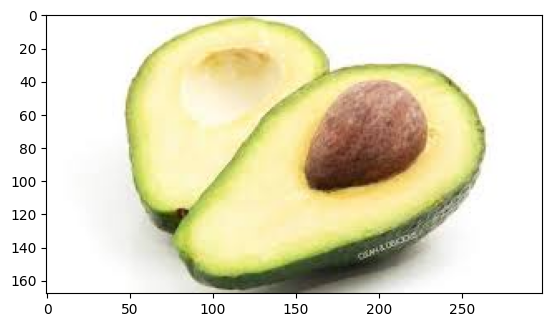

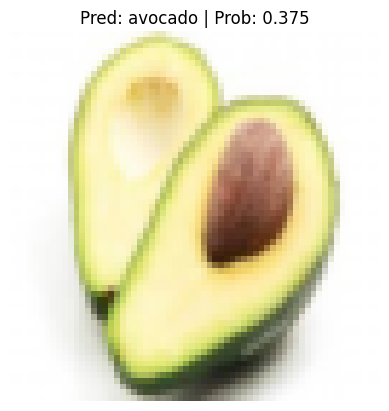

In [36]:
fruit_image_path = os.path.join(predict_dir, "img_41.jpeg")
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()
predictImage(model=first_model,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

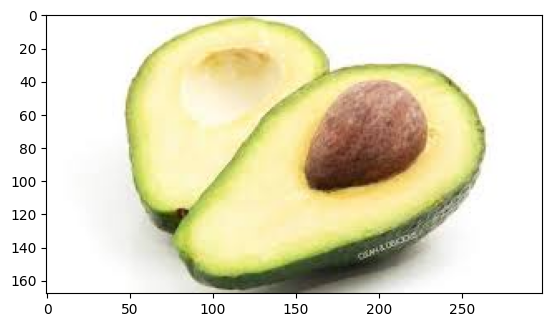

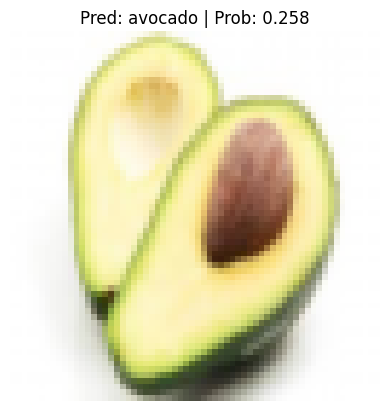

In [37]:
fruit_image_path = os.path.join(predict_dir, "img_41.jpeg")
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()
predictImage(model=model_two,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

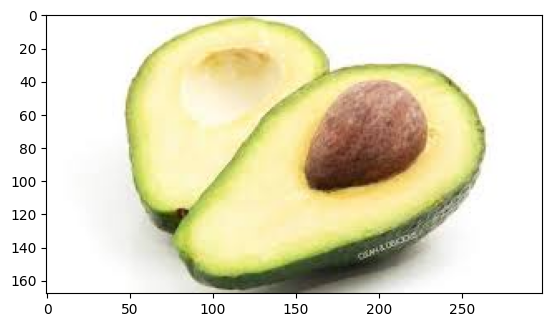

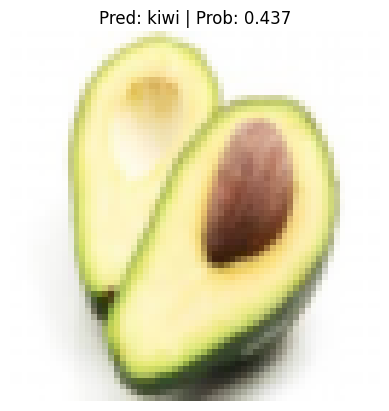

In [38]:
fruit_image_path = os.path.join(predict_dir, "img_41.jpeg")
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()
predictImage(model=model_3,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

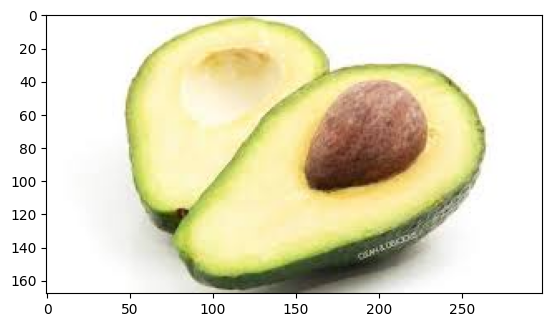

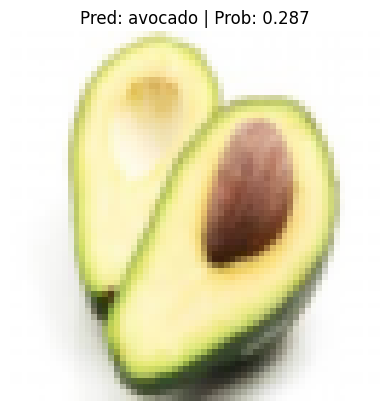

In [39]:
fruit_image_path = os.path.join(predict_dir, "img_41.jpeg")
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()
predictImage(model=model_4,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

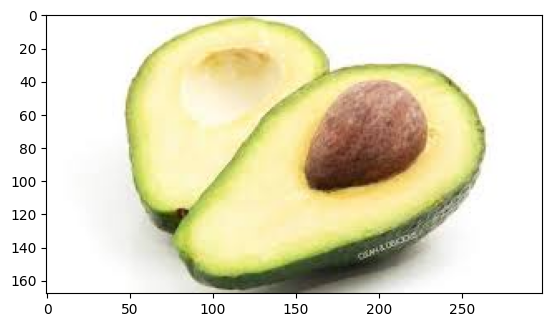

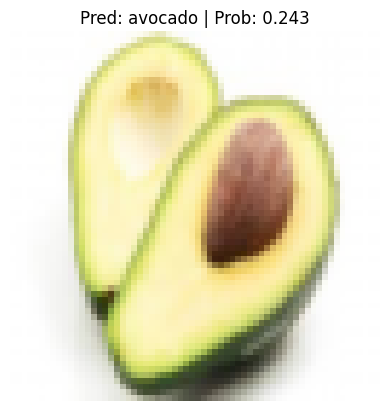

In [40]:
fruit_image_path = os.path.join(predict_dir, "img_41.jpeg")
img = mpimg.imread(fruit_image_path)
imgplot = plt.imshow(img)
plt.show()
predictImage(model=model_5,
                    image_path=fruit_image_path,
                    class_names=train_data.classes,
                    transform=fruit_image_transform,
                    device=device)

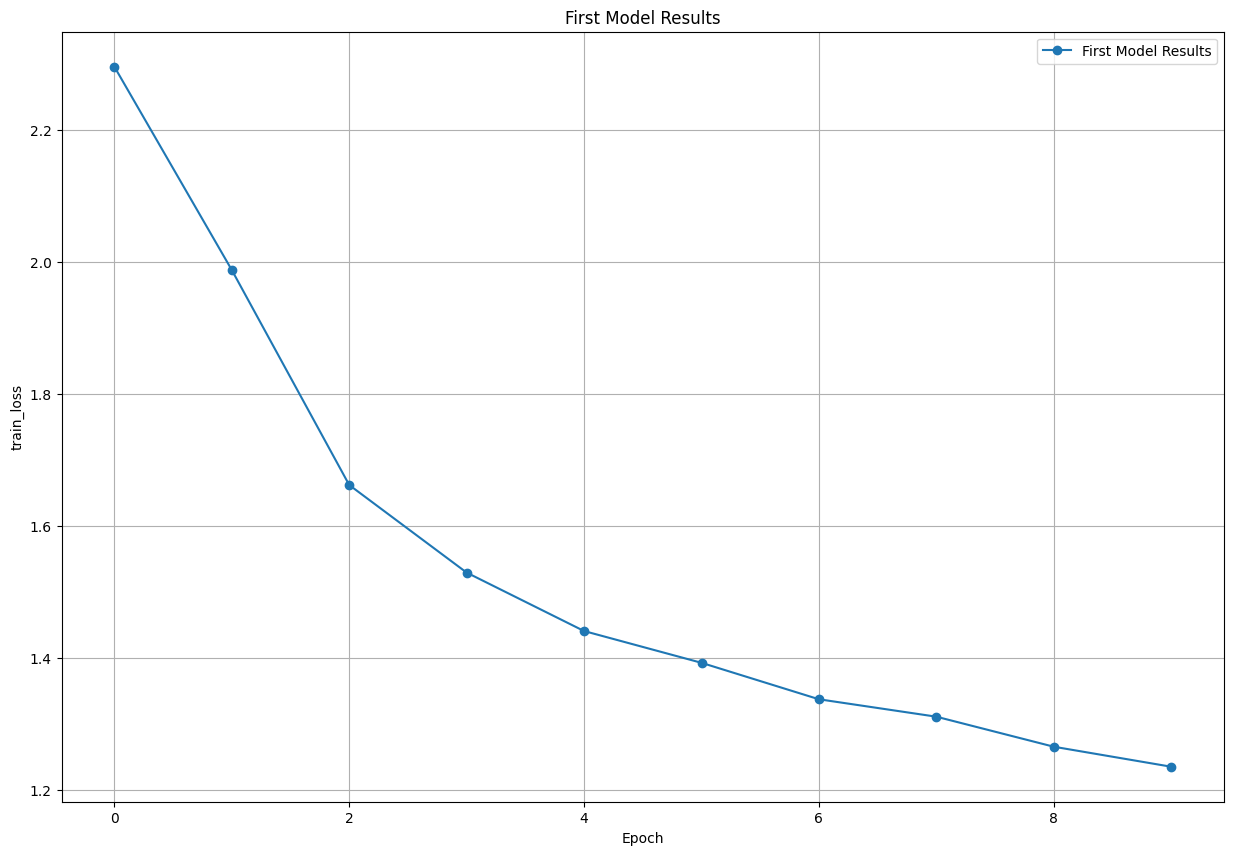

In [41]:
# Plot graph of train_loss for the first model
plt.figure(figsize=(15, 10))
plt.plot(first_model_df["train_loss"] , marker='o', label='First Model Results')
plt.title('First Model Results')
plt.xlabel('Epoch')
plt.ylabel('train_loss')
plt.legend()
plt.grid(True)
plt.show()